In [4]:
!pip install "numpy<2" "Pillow==9.5.0" facenet-pytorch opencv-python tqdm -q

import os
import cv2
import json
import torch
from facenet_pytorch import MTCNN
from tqdm import tqdm

In [5]:
# --- PATHS ---
INPUT_DIR = '/kaggle/input/datasets/francisbawa/df-dataset'
OUTPUT_DIR = '/kaggle/working/face_dataset'
REAL_DIR = os.path.join(OUTPUT_DIR, 'real')
FAKE_DIR = os.path.join(OUTPUT_DIR, 'fake')

os.makedirs(REAL_DIR, exist_ok=True)
os.makedirs(FAKE_DIR, exist_ok=True)

with open(os.path.join(INPUT_DIR, 'metadata.json')) as f:
    metadata = json.load(f)

# --- INITIALIZE MTCNN ON GPU ---
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Running MTCNN Face Extractor on: {device}")
mtcnn = MTCNN(keep_all=False, select_largest=True, post_process=False, device=device)

def process_video_mtcnn(video_filename, label, frames_per_video=5):
    video_path = os.path.join(INPUT_DIR, video_filename)
    cap = cv2.VideoCapture(video_path)
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0: return
    
    skip_frames = max(1, total_frames // frames_per_video)
    frame_count = 0
    saved_count = 0
    
    while cap.isOpened() and saved_count < frames_per_video:
        ret, frame = cap.read()
        if not ret: break
            
        if frame_count % skip_frames == 0:
            # OpenCV reads in BGR, MTCNN expects RGB
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Detect faces
            boxes, _ = mtcnn.detect(frame_rgb)
            
            if boxes is not None:
                box = boxes[0] # Grab the largest face detected
                x1, y1, x2, y2 = [int(b) for b in box]
                
                # Ensure coordinates are within image boundaries
                ih, iw, _ = frame.shape
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(iw, x2), min(ih, y2)
                
                face_crop = frame[y1:y2, x1:x2]
                
                if face_crop.size != 0:
                    # Resize to 224x224 for our EfficientNet model
                    face_crop = cv2.resize(face_crop, (224, 224))
                    save_dir = REAL_DIR if label == 'REAL' else FAKE_DIR
                    save_path = os.path.join(save_dir, f"{video_filename.split('.')[0]}_frame{frame_count}.jpg")
                    cv2.imwrite(save_path, face_crop)
                    saved_count += 1
                    
        frame_count += 1
    cap.release()

# --- EXECUTION ---
videos = [f for f in os.listdir(INPUT_DIR) if f.endswith('.mp4')]
print(f"Found {len(videos)} videos. Starting extraction...")

for video in tqdm(videos):
    label = metadata[video]['label']
    process_video_mtcnn(video, label, frames_per_video=5)

print("Extraction complete! Check /kaggle/working/face_dataset")

Running MTCNN Face Extractor on: cuda:0
Found 400 videos. Starting extraction...


100%|██████████| 400/400 [11:13<00:00,  1.68s/it]

Extraction complete! Check /kaggle/working/face_dataset


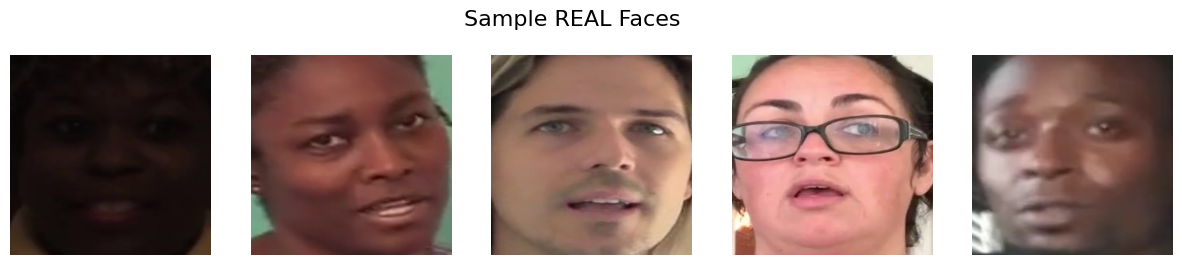

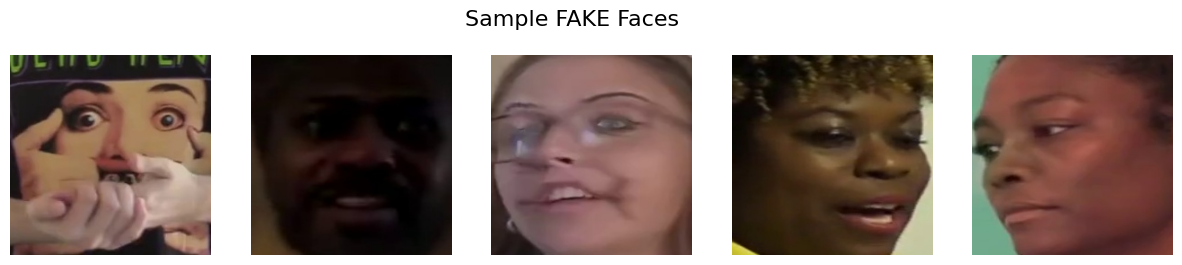

In [7]:
import matplotlib.pyplot as plt
import glob
import random
import cv2

def show_random_faces(folder_path, title):
    # Grab all current images in the folder
    images = glob.glob(f"{folder_path}/*.jpg")
    
    if len(images) < 5:
        print(f"Waiting for more images in {title} folder...")
        return
        
    # Pick 5 random faces
    sample_images = random.sample(images, 5)
    
    # Plot them in a row
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(title, fontsize=16)
    
    for i, img_path in enumerate(sample_images):
        # OpenCV reads as BGR, matplotlib expects RGB
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].axis('off')
        
    plt.show()

# Show 5 REAL and 5 FAKE faces
show_random_faces('/kaggle/working/face_dataset/real', 'Sample REAL Faces')
show_random_faces('/kaggle/working/face_dataset/fake', 'Sample FAKE Faces')

In [8]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# --- 1. DEFINE THE DATASET CLASS ---
class DeepfakeDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None):
        self.real_paths = glob.glob(os.path.join(real_dir, '*.jpg'))
        self.fake_paths = glob.glob(os.path.join(fake_dir, '*.jpg'))
        
        self.all_paths = self.real_paths + self.fake_paths
        
        # Labels: 0 for REAL, 1 for FAKE
        self.labels = [0] * len(self.real_paths) + [1] * len(self.fake_paths)
        self.transform = transform
        
        print(f"Dataset loaded: {len(self.real_paths)} Real faces, {len(self.fake_paths)} Fake faces.")
        
    def __len__(self):
        return len(self.all_paths)
        
    def __getitem__(self, idx):
        img_path = self.all_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

# --- 2. IMAGE TRANSFORMATIONS ---
# Standard ImageNet normalization required by EfficientNet
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 3. CREATE THE DATALOADER ---
REAL_DIR = '/kaggle/working/face_dataset/real'
FAKE_DIR = '/kaggle/working/face_dataset/fake'

dataset = DeepfakeDataset(REAL_DIR, FAKE_DIR, transform=data_transforms)

# We shuffle the data so the model doesn't just learn a string of "Reals" followed by "Fakes"
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

print("DataLoader is ready to feed the model!")

Dataset loaded: 380 Real faces, 1551 Fake faces.
DataLoader is ready to feed the model!


In [9]:
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# 1. Ensure we are using the Kaggle GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Building model on: {device}")

# 2. Load the pre-trained EfficientNet-B0 model
# We use pre-trained weights so the model already knows how to recognize edges, shapes, and facial features
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# 3. Modify the Classification Head
# EfficientNet was originally trained to guess 1000 different objects.
# We just need it to guess 2 things: Real (0) or Fake (1).
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)

# 4. Send the model to the GPU
model = model.to(device)

print("EfficientNet-B0 is ready and modified for 2-class classification!")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


Building model on: cuda:0


100%|██████████| 20.5M/20.5M [00:00<00:00, 128MB/s] 


EfficientNet-B0 is ready and modified for 2-class classification!


In [10]:
import torch.optim as optim

# 1. Setup the Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
# Adam optimizer with a small learning rate is standard for fine-tuning
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
print("Starting Training Loop...")

# 2. The Training Loop
for epoch in range(epochs):
    model.train() # Put model in training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    # Loop through the batches of images in our DataLoader
    for images, labels in dataloader:
        # Move images and labels to the GPU
        images, labels = images.to(device), labels.to(device)
        
        # Zero the gradients so they don't compound
        optimizer.zero_grad()
        
        # Forward pass: Have the model guess
        outputs = model(images)
        
        # Calculate how wrong the model was
        loss = criterion(outputs, labels)
        
        # Backward pass: Update the weights based on the loss
        loss.backward()
        optimizer.step()
        
        # Track statistics
        running_loss += loss.item()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()
        
    # Calculate epoch metrics
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct_predictions / total_samples
    
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

# 3. Save the Model Weights
# This is the golden file we will download to your Mac!
save_path = '/kaggle/working/deepfake_efficientnet.pth'
torch.save(model.state_dict(), save_path)
print(f"Training Complete! Model saved successfully to {save_path}")

Starting Training Loop...
Epoch [1/5] | Loss: 0.3827 | Accuracy: 83.27%
Epoch [2/5] | Loss: 0.2117 | Accuracy: 91.87%
Epoch [3/5] | Loss: 0.1309 | Accuracy: 95.24%
Epoch [4/5] | Loss: 0.1069 | Accuracy: 95.70%
Epoch [5/5] | Loss: 0.0849 | Accuracy: 97.10%
Training Complete! Model saved successfully to /kaggle/working/deepfake_efficientnet.pth
